# Introduction to Rosette Simulation (Python)

This notebook demonstrates the **Rosette simulation framework** from the `rosace` Python package — a port of the R rosace Rosette vignette.

Rosette lets you:
- Generate synthetic DMS (Deep Mutational Scanning) data with known ground-truth effects
- Simulate count trajectories across growth rounds
- Estimate sequencing and library dispersions
- Score variants using Simple Linear Regression (SLR)
- Benchmark recovery of true effects

No external data is required; everything is generated synthetically with `seed=42` for reproducibility.

In [1]:
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rosace.run_rosette import generate_effect, generate_count
from rosace.preprocessing import filter_data, impute_data, normalize_data
from rosace.assay import AssayGrowth
from rosace.slr import run_slr
from rosace.utils import estimate_disp, estimate_disp_start, output_score

## Simulation Configuration

We define a dictionary that controls both effect generation and count simulation.

| Parameter | Description |
|---|---|
| `n_pos` | Number of protein positions |
| `n_mut` | Mutations per position |
| `neg_frac` / `pos_frac` | Fraction of variants that are loss-of-function / gain-of-function |
| `rounds` | Growth rounds (timepoints = rounds + 1) |
| `n_reps` | Biological replicates |
| `init_count` | Initial library count per variant |
| `depth` | Sequencing depth per timepoint |
| `disp` | Sequencing (NB) dispersion |
| `disp_start` | Library preparation dispersion |

In [2]:
sim_config = {
    "n_pos": 30,
    "n_mut": 19,
    "var_label": ["Neutral", "Neg", "Pos"],
    "neutral_mean": 0.0, "neutral_sd": 0.1,
    "neg_mean": -1.5,    "neg_sd": 0.3,
    "pos_mean": 0.8,     "pos_sd": 0.2,
    "neg_frac": 0.30,    "pos_frac": 0.10,
    "rounds": 3,
    "n_reps": 2,
    "init_count": 200,
    "depth": 500_000,
    "disp": 0.05,
    "disp_start": 0.1,
    "seed": 42,
}
print("Configuration ready.")

Configuration ready.


## Step 1: Generate Ground-Truth Effects

`generate_effect` draws variant effects from Gaussian distributions parameterized by class (Neutral / Neg / Pos).

In [3]:
effects = generate_effect(sim_config)
print(f"Generated {len(effects)} variants across {sim_config['n_pos']} positions")
print()
print("Label distribution:")
print(effects['label'].value_counts())
effects.head(10)

Generated 570 variants across 30 positions

Label distribution:
label
Neutral    348
Neg        159
Pos         63
Name: count, dtype: int64


,variant,pos,mut,effect,label
0,p1m0,1,0,-1.811995,Neg
1,p1m1,1,1,-1.217831,Neg
2,p1m2,1,2,-0.130218,Neutral
3,p1m3,1,3,-1.594873,Neg
4,p1m4,1,4,-0.085304,Neutral
5,p1m5,1,5,0.077779,Neutral
6,p1m6,1,6,-1.161828,Neg
7,p1m7,1,7,-0.085929,Neutral
8,p1m8,1,8,-0.095888,Neutral
9,p1m9,1,9,-1.514978,Neg


## Step 2: Visualise Effect Distribution

Neutral variants cluster around 0; negative (LOF) variants have large negative effects; positive (GOF) variants have moderately positive effects.

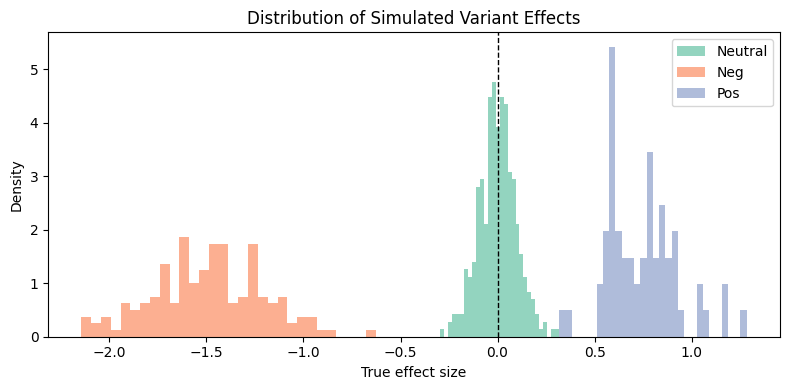

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
palette = {"Neutral": "#66C2A5", "Neg": "#FC8D62", "Pos": "#8DA0CB"}
for label, color in palette.items():
    subset = effects[effects['label'] == label]['effect']
    ax.hist(subset, bins=30, alpha=0.7, label=label, color=color, density=True)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel("True effect size")
ax.set_ylabel("Density")
ax.set_title("Distribution of Simulated Variant Effects")
ax.legend()
plt.tight_layout()
plt.show()

## Step 3: Simulate Sequencing Counts

`generate_count` propagates variant frequencies through growth rounds (Poisson growth noise) and then applies negative-binomial sequencing sampling.

In [5]:
counts_df = generate_count(sim_config, effects)
print(f"Simulated count matrix shape: {counts_df.shape}")
print("Columns:", counts_df.columns.tolist())
counts_df.head()

Simulated count matrix shape: (570, 9)
Columns: ['variant', 'rep_1_t0', 'rep_1_t1', 'rep_1_t2', 'rep_1_t3', 'rep_2_t0', 'rep_2_t1', 'rep_2_t2', 'rep_2_t3']


,variant,rep_1_t0,rep_1_t1,rep_1_t2,rep_1_t3,rep_2_t0,rep_2_t1,rep_2_t2,rep_2_t3
0,p1m0,1035,206,29,2,486,111,9,0
1,p1m1,327,154,38,9,1400,465,103,18
2,p1m2,821,822,747,321,413,472,246,107
3,p1m3,756,182,41,4,948,177,22,0
4,p1m4,1245,916,702,405,1049,1141,668,359


## Step 4: Count Trajectories per Variant Class

We plot log-normalised frequency trajectories (relative to t=0) for a handful of representative variants.  
Negative variants deplete over time; positive variants enrich.

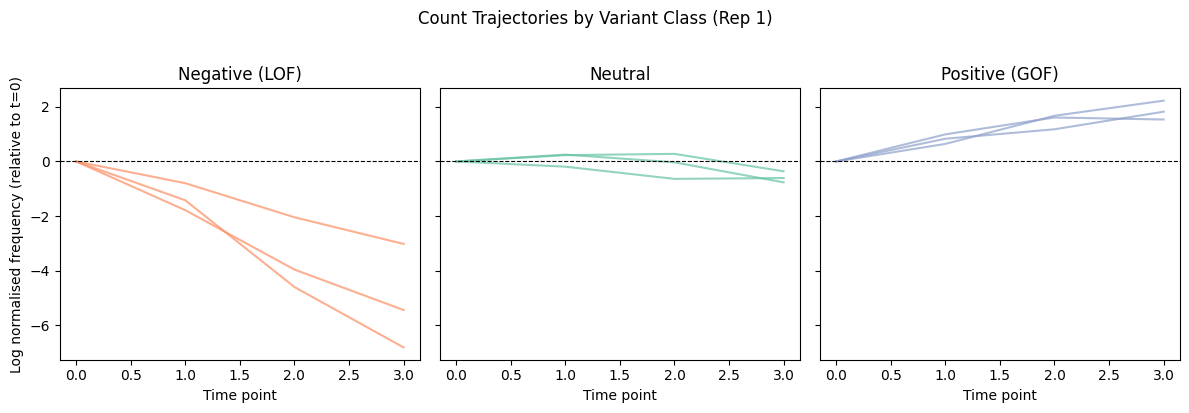

In [6]:
rng = np.random.default_rng(0)
sample_neg = effects[effects['label'] == 'Neg']['variant'].sample(3, random_state=0).tolist()
sample_pos = effects[effects['label'] == 'Pos']['variant'].sample(3, random_state=0).tolist()
sample_neu = effects[effects['label'] == 'Neutral']['variant'].sample(3, random_state=0).tolist()

rep_cols_t = [f'rep_1_t{t}' for t in range(sim_config['rounds'] + 1)]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, (label, variants, color) in zip(axes, [
    ("Negative (LOF)", sample_neg, "#FC8D62"),
    ("Neutral",        sample_neu, "#66C2A5"),
    ("Positive (GOF)", sample_pos, "#8DA0CB"),
]):
    for v in variants:
        row = counts_df[counts_df['variant'] == v]
        if len(row) == 0:
            continue
        y = row[rep_cols_t].values[0].astype(float)
        total = counts_df[rep_cols_t].sum(axis=0).values.astype(float) + 0.5
        freq = (y + 0.5) / total
        log_freq = np.log(freq)
        log_freq -= log_freq[0]
        ax.plot(range(len(log_freq)), log_freq, color=color, alpha=0.7, linewidth=1.5)
    ax.set_xlabel("Time point")
    ax.set_title(f"{label}")
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_ylabel("Log normalised frequency (relative to t=0)")
plt.suptitle("Count Trajectories by Variant Class (Rep 1)", y=1.02)
plt.tight_layout()
plt.show()

## Step 5: Estimate Sequencing and Library Dispersion

`estimate_disp` estimates the sequencing (NB) dispersion; `estimate_disp_start` estimates the library preparation dispersion.  
Both are estimated from the raw count data and can be compared against the known simulation parameters.

In [7]:
n_rounds = sim_config['rounds']
rep1_cols = [f'rep_1_t{t}' for t in range(n_rounds + 1)]
counts_matrix = counts_df[rep1_cols].values.astype(float)
var_names = counts_df['variant'].tolist()

assay1 = AssayGrowth(
    counts=counts_matrix,
    var_names=var_names,
    key='sim',
    rep=1,
)

disp_est       = estimate_disp(assay1)
disp_start_est = estimate_disp_start(assay1)

print(f"Estimated sequencing dispersion:  {disp_est:.4f}  (true: {sim_config['disp']:.4f})")
print(f"Estimated library dispersion:     {disp_start_est:.4f}  (true: {sim_config['disp_start']:.4f})")

Estimated sequencing dispersion:  4.9131  (true: 0.0500)
Estimated library dispersion:     0.1641  (true: 0.1000)


## Step 6: Preprocess Data and Run Simple Linear Regression (SLR)

The preprocessing pipeline:
1. **Filter** low-count variants
2. **Impute** missing / zero counts (`method='zero'` replaces zeros with 0)
3. **Normalise** to log-ratio growth scores (`method='total'` uses total library size)

SLR then fits a line through the time-course for each variant; the slope is the functional score.

In [8]:
assay1_filt = filter_data(assay1)
assay1_imp  = impute_data(assay1_filt, method='zero')
assay1_norm = normalize_data(assay1_imp, method='total')

score      = run_slr(assay1_norm)
scores_df  = output_score(score)

print(f"Scored {len(scores_df)} variants")
print("\nFirst 10 SLR scores:")
scores_df.head(10)

Scored 570 variants

First 10 SLR scores:


,variant,mean,sd,lfsr,label
0,p1m0,-2.015284,0.139609,1.553176e-47,Neg
1,p1m1,-1.213801,0.116997,1.617807e-25,Neg
2,p1m2,-0.303790,0.143852,1.735085e-02,Neg
3,p1m3,-1.698281,0.137687,2.957403e-35,Neg
4,p1m4,-0.376031,0.046389,2.615696e-16,Neg
5,p1m5,-0.063159,0.107090,2.776714e-01,Neutral
6,p1m6,-1.418337,0.229029,2.954685e-10,Neg
7,p1m7,-0.143690,0.159820,1.843076e-01,Neutral
8,p1m8,-0.302454,0.090135,3.960307e-04,Neg
9,p1m9,-2.101262,0.033582,0.000000e+00,Neg


## Step 7: Evaluate Recovery of True Effects

We merge the SLR scores with the ground-truth effects and compute a Pearson correlation.  
A strong positive correlation indicates that SLR successfully recovers the simulated biology.

Score–effect Pearson correlation: r = 0.974


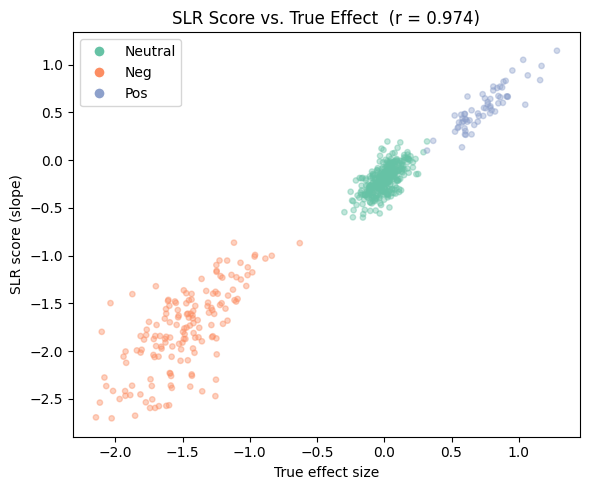

In [9]:
# scores_df already has a 'label' column; drop it before merging to avoid ambiguity
merged = scores_df.drop(columns=['label']).merge(
    effects[['variant', 'effect', 'label']], on='variant', how='inner'
)
r = merged['mean'].corr(merged['effect'])
print(f"Score–effect Pearson correlation: r = {r:.3f}")

palette = {"Neutral": "#66C2A5", "Neg": "#FC8D62", "Pos": "#8DA0CB"}
colors  = merged['label'].map(palette)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(merged['effect'], merged['mean'], c=colors, alpha=0.4, s=15)
ax.set_xlabel("True effect size")
ax.set_ylabel("SLR score (slope)")
ax.set_title(f"SLR Score vs. True Effect  (r = {r:.3f})")

from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=l)
    for l, c in palette.items()
]
ax.legend(handles=legend_elems)
plt.tight_layout()
plt.show()

## Step 8: Full Pipeline via `run_rosette`

`run_rosette` is a convenience function that generates effects and counts and saves them as TSV files.  
Here we direct output to a temporary directory and inspect the saved files.

In [10]:
import tempfile, os
from rosace.run_rosette import run_rosette

with tempfile.TemporaryDirectory() as tmpdir:
    full_config = {**sim_config, "output_dir": tmpdir, "n_pos": 20, "n_mut": 10}
    run_rosette(full_config)

    for fname in sorted(os.listdir(tmpdir)):
        fpath = os.path.join(tmpdir, fname)
        df = pd.read_csv(fpath, sep='\t')
        print(f"  {fname}: shape={df.shape}")
        print(df.head(3).to_string())
        print()

  counts.tsv: shape=(200, 9)
  variant  rep_1_t0  rep_1_t1  rep_1_t2  rep_1_t3  rep_2_t0  rep_2_t1  rep_2_t2  rep_2_t3
0    p1m0      2963       530        79         0      1935       394        90         0
1    p1m1       847       376       110        65      2283       686        78        13
2    p1m2      2239      1759      2038       760      2336      1675      1801       901

  effects.tsv: shape=(200, 5)
  variant  pos  mut    effect    label
0    p1m0    1    0 -1.811995      Neg
1    p1m1    1    1 -1.217831      Neg
2    p1m2    1    2 -0.130218  Neutral

  rosette.tsv: shape=(200, 13)
  variant  pos  mut    effect    label  rep_1_t0  rep_1_t1  rep_1_t2  rep_1_t3  rep_2_t0  rep_2_t1  rep_2_t2  rep_2_t3
0    p1m0    1    0 -1.811995      Neg      2963       530        79         0      1935       394        90         0
1    p1m1    1    1 -1.217831      Neg       847       376       110        65      2283       686        78        13
2    p1m2    1    2 -0.130218  Neut

## Summary

| Component | What it does |
|---|---|
| `generate_effect` | Draws true variant effects from per-class Gaussians |
| `generate_count` | Simulates NB-distributed read counts over growth rounds |
| `estimate_disp` | Estimates sequencing (NB) dispersion from raw counts |
| `estimate_disp_start` | Estimates library preparation dispersion |
| `filter_data` | Removes low-coverage variants |
| `impute_data` | Handles zero / missing counts |
| `normalize_data` | Computes log-ratio growth scores |
| `run_slr` | Simple Linear Regression scoring (slope per variant) |
| `run_rosette` | End-to-end pipeline writing TSV outputs |

Rosette simulation makes it easy to benchmark scoring methods against data with known ground truth, a key step before applying the full Bayesian ROSACE model to real experimental data.